In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
ensemble_members_dict = {'ECHAM5':['ens01', 'ens02', 'ens03', 'ens04', 'ens05', 'ens06', 'ens07', 'ens08', 'ens09', 'ens10', 'ens11', 'ens12', 'ens13', 'ens14', 'ens15', 'ens16', 'ens17', 'ens18', 'ens19', 'ens20', 'ens21', 'ens22', 'ens23', 'ens24', 'ens25',\
                                    'ens26', 'ens27', 'ens28', 'ens29', 'ens30', 'ens31', 'ens32', 'ens33', 'ens34', 'ens35', 'ens36', 'ens37', 'ens38', 'ens39', 'ens40', 'ens41', 'ens42', 'ens43', 'ens44', 'ens45', 'ens46', 'ens47', 'ens48', 'ens49', 'ens50'],
                         'HadGEM3':['r1i1p1','r1i1p11','r1i1p13','r1i1p15','r1i1p3','r1i1p5','r1i1p7','r1i1p9',
                                    'r1i1p10','r1i1p12','r1i1p14','r1i1p2','r1i1p4','r1i1p6','r1i1p8'],
                         'd4PDF':['m001', 'm002', 'm003', 'm004', 'm005', 'm006', 'm007', 'm008', 'm009', 'm010', 'm011', 'm012', 'm013', 'm014', 'm015', 'm016', 'm017', 'm018', 'm019', 'm020', 'm021', 'm022', 'm023', 'm024', 'm025', \
                                  'm026', 'm027', 'm028', 'm029', 'm030', 'm031', 'm032', 'm033', 'm034', 'm035', 'm036', 'm037', 'm038', 'm039', 'm040', 'm041', 'm042', 'm043', 'm044', 'm045', 'm046', 'm047', 'm048', 'm049', 'm050', \
                                  'm051', 'm052', 'm053', 'm054', 'm055', 'm056', 'm057', 'm058', 'm059', 'm060', 'm061', 'm062', 'm063', 'm064', 'm065', 'm066', 'm067', 'm068', 'm069', 'm070', 'm071', 'm072', 'm073', 'm074', 'm075', \
                                  'm076', 'm077', 'm078', 'm079', 'm080', 'm081', 'm082', 'm083', 'm084', 'm085', 'm086', 'm087', 'm088', 'm089', 'm090', 'm091', 'm092', 'm093', 'm094', 'm095', 'm096', 'm097', 'm098', 'm099', 'm100']}
font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

In [ ]:
#PROCESSING HadGEM3 UA DATA

def concat_time(direc,files):
    da_list = []
    for f in files:
        da = xr.open_dataset(direc + f).ua.sel(lat=slice(-90,0),lon=slice(160,200))
        
        da_list.append(da)
        
    mem_da = xr.concat(da_list,dim='time')
    
    return(mem_da)

ens_da_list = []
for mem in ensemble_members_dict['HadGEM3']:
    print(mem)
    direc = '/nesi/project/niwa00015/models/C20C/MOHC/HadGEM3-A-N216/All-Hist/est1/v1-0/mon/atmos/ua/'+mem+'/'
    files = os.listdir(direc)
    
    mem_da = concat_time(direc,files)
    
    ens_da_list.append(mem_da)

ens_ds = xr.concat(ens_da_list,dim='member')
ens_mean_ds = ens_ds.mean('member')

ens_mean_ds.to_netcdf('/nesi/project/niwa02986/queenle/data/HadGEM3/ua_Amon-NZ_HadGEM3_all_ensMean_1960-2015.nc')
ens_mean_ds.mean('lon').to_netcdf('/nesi/project/niwa02986/queenle/data/HadGEM3/ua_Amon-zonal-NZ_HadGEM3_all_ensMean_1960-2015.nc')


#PROCESSING ECHAM5 UA DATA

ECHAM5_ua = xr.open_dataarray('/nesi/project/niwa02986/C20C/NOAA-ESRLandCIRES/ECHAM5-4/All-Hist/est1/v1-0/mon/atmos/ua/ensmean/ua_Amon_ECHAM5-4_All-Hist_est1_v1-0_mean_197901-202102.nc')

NZ = ECHAM5_ua.sel(lat=slice(0,-90),lon=slice(160,200))

NZ.to_netcdf('/nesi/project/niwa02986/queenle/data/ECHAM5/ua_Amon-NZ_ECHAM5_all_ensMean_1979-2021.nc')
NZ.mean('lon').to_netcdf('/nesi/project/niwa02986/queenle/data/ECHAM5/ua_Amon-zonal-NZ_ECHAM5_all_ensMean_1979-2021.nc')


#PROCESS d4PDF UA DATA

da_list = []
for mem in ensemble_members_dict['d4PDF']:
    print(mem)
    mem_da = xr.open_dataarray('/nesi/project/niwa02986/C20C/d4PDF/MRI-AGCM3-2H/HPB/est1/v1-0/mon/atmos/ua/'+mem+'/ua_Amon_d4PDF_HPB_'+mem+'_195101-201112.nc')
    mem_da = mem_da.sel(lat=slice(-90,0),lon=slice(160,200))
    #mem_da = mem_da.sel(lev=850)
    mem_da = mem_da.resample(time = 'QS-DEC').mean()
    
    da_list.append(mem_da)

ens_ds = xr.concat(da_list,dim='member')
ens_mean = ens_ds.mean('member')
ens_mean.to_netcdf('/nesi/project/niwa02986/queenle/data/d4pdf/NZ/HPB/UA/ua_d4PDF_HPB_ensMean_195101-201112.nc')
ens_mean.mean('lon').to_netcdf('/nesi/project/niwa02986/queenle/data/d4pdf/NZ/HPB/UA/ua_zonal_d4PDF_HPB_ensMean_195101-201112.nc')



r1i1p1


In [6]:
'''
Load wind data for HadGEM3, ECHAM5, d4PDF
'''

d4PDF_ua_surface = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/NZ/HPB/UA/ua_zonal_d4PDF_HPB_ensMean_195101-201112.nc')

ECHAM5_ua = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/ECHAM5/ua_Amon-zonal-NZ_ECHAM5_all_ensMean_1979-2021.nc')
ECHAM5_ua_surface = ECHAM5_ua.sel(plev=85000)
ECHAM5_ua_surface = ECHAM5_ua_surface.resample(time = 'QS-DEC').mean()

HadGEM3_ua = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/HadGEM3/ua_Amon-zonal-NZ_HadGEM3_all_ensMean_1960-2015.nc')
HadGEM3_ua_surface = HadGEM3_ua.sel(plev=85000)
HadGEM3_ua_surface = HadGEM3_ua_surface.resample(time = 'QS-DEC').mean()

# Read in ERA data
data = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/ERA_u_wind.nc')
ERA5 = data.u.isel(expver=0).sel(level=850).resample(time = 'QS-DEC').mean()
ERA5 = ERA5.mean('longitude')

da_dict = {'ERA5':ERA5,
           'HadGEM3':HadGEM3_ua_surface,
           'ECHAM5':ECHAM5_ua_surface,
           'd4PDF':d4PDF_ua_surface}

shared_time_da_dict = {'ERA5':ERA5.sel(time=slice('1979','2015')),
                       'HadGEM3':HadGEM3_ua_surface.sel(time=slice('1979','2015')),
                       'ECHAM5':ECHAM5_ua_surface.sel(time=slice('1979','2015')),
                       'd4PDF':d4PDF_ua_surface.sel(time=slice('1979','2015'))}

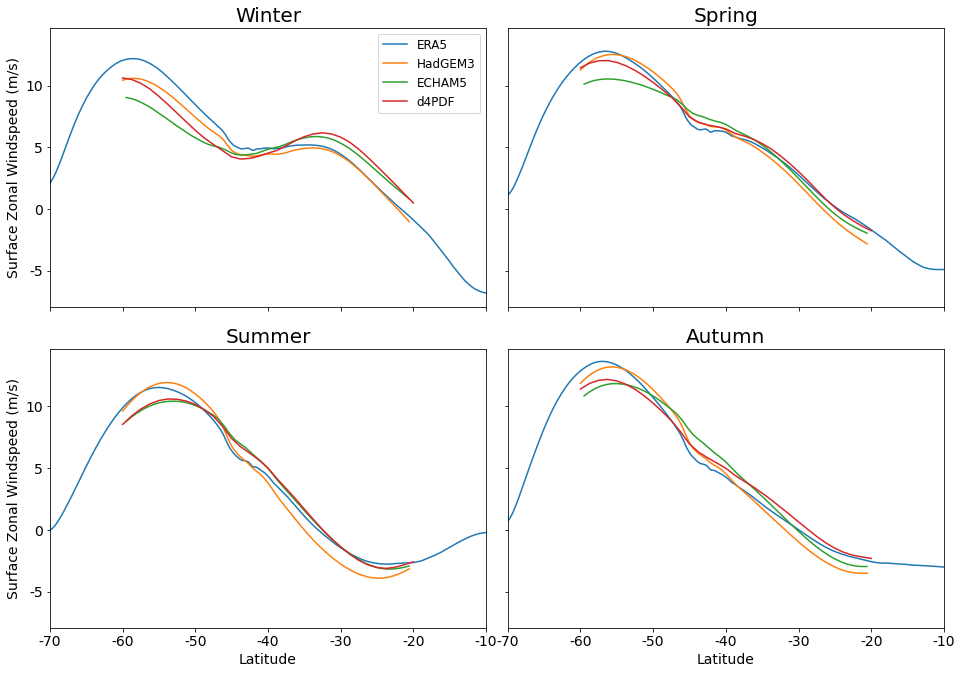

In [47]:
fig,axs = plt.subplots(2,2,figsize=(14,10),sharex=True,sharey=True)
axs = axs.flatten()

seasons = ['Winter','Spring','Summer','Autumn']
for i,season in enumerate([6,9,12,3]):
    
    ax.axvspan(-46.56, -35.23, alpha=0.3, color='grey')
    
    for model in da_dict:
        
        season_da = da_dict[model].sel(time=da_dict[model].time.dt.month.isin([season])).mean('time')
        
        season_da.plot(ax=axs[i],label=model)
        
    axs[i].set_xlim(-70,-10)
    axs[i].set_title(seasons[i],fontdict=font)
    
    if i == 0 or i == 2:
        font['size'] = 14
        axs[i].set_yticks([-5,0,5,10])
        axs[i].set_yticklabels(['-5','0','5','10'],fontdict=font)
        axs[i].set_ylabel('Surface Zonal Windspeed (m/s)',fontdict=font)
        font['size']=20
        
    else:
        axs[i].set_ylabel('')
        
    if i == 2 or i == 3:
        font['size'] = 14
        axs[i].set_xticks([-70, -60, -50, -40, -30, -20, -10])
        axs[i].set_xticklabels(['-70', '-60', '-50', '-40', '-30', '-20', '-10'],fontdict=font)
        axs[i].set_xlabel('Latitude',fontdict=font)
        font['size']=20 
    else:
        axs[i].set_xlabel('')
        
axs[0].legend(fontsize=12)

plt.tight_layout(pad=3)
plt.subplots_adjust(hspace=0.15,wspace=0.05)

fig.patch.set_alpha(1)

fig.savefig('/home/queenle/hydro_attribution/dissertation/figures/surface_wind_validation.png',dpi=300)

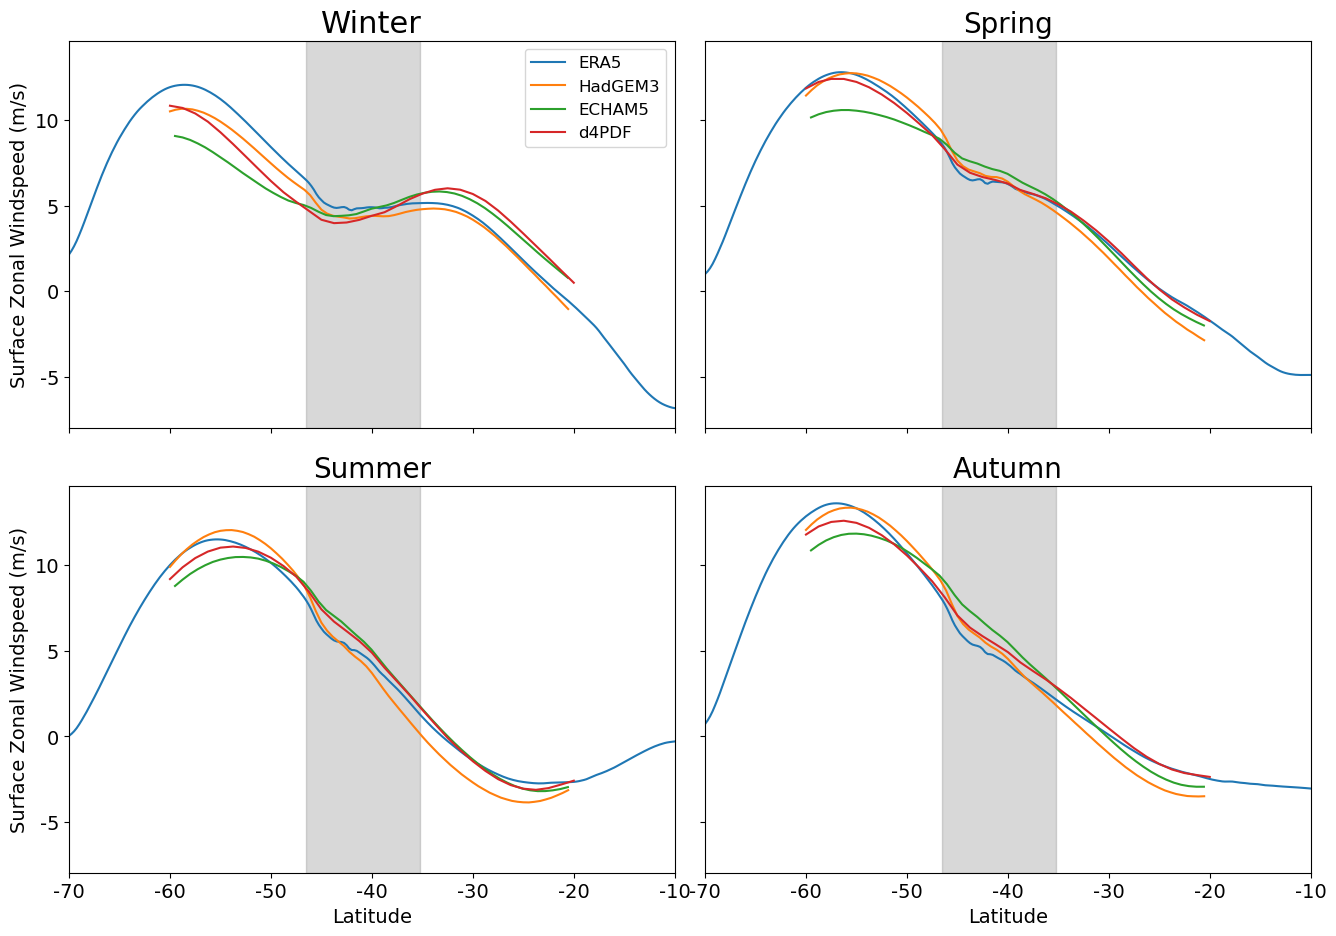

In [7]:
fig,axs = plt.subplots(2,2,figsize=(14,10),sharex=True,sharey=True)
axs = axs.flatten()

seasons = ['Winter','Spring','Summer','Autumn']
for i,season in enumerate([6,9,12,3]):
    
    axs[i].axvspan(-46.56, -35.23, alpha=0.3, color='grey')
    
    for model in shared_time_da_dict:
        
        season_da = shared_time_da_dict[model].sel(time=shared_time_da_dict[model].time.dt.month.isin([season])).mean('time')
        
        season_da.plot(ax=axs[i],label=model)
        
    axs[i].set_xlim(-70,-10)
    axs[i].set_title(seasons[i],fontdict=font)
    
    if i == 0 or i == 2:
        font['size'] = 14
        axs[i].set_yticks([-5,0,5,10])
        axs[i].set_yticklabels(['-5','0','5','10'],fontdict=font)
        axs[i].set_ylabel('Surface Zonal Windspeed (m/s)',fontdict=font)
        font['size']=20
        
    else:
        axs[i].set_ylabel('')
        
    if i == 2 or i == 3:
        font['size'] = 14
        axs[i].set_xticks([-70, -60, -50, -40, -30, -20, -10])
        axs[i].set_xticklabels(['-70', '-60', '-50', '-40', '-30', '-20', '-10'],fontdict=font)
        axs[i].set_xlabel('Latitude',fontdict=font)
        font['size']=20 
    else:
        axs[i].set_xlabel('')
        
axs[0].legend(fontsize=12)

plt.tight_layout(pad=3)
plt.subplots_adjust(hspace=0.15,wspace=0.05)

fig.patch.set_alpha(1)

fig.savefig('/home/queenle/hydro_attribution/dissertation/figures/surface_wind_validation_1979_2015.png',dpi=300)